scenario 1 :

Ratings Shape: (100836, 4)
Movies Shape: (9742, 3)

--- Ratings Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None

--- Missing Values ---
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

--- Sample Data ---
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

User-Item Matrix Shape: (610, 9724)

User Similarity Matrix Shape: (610, 610)

Top similar users for User 1:
userId
266    0.357408
313    0.351562
368    0.345127
57   

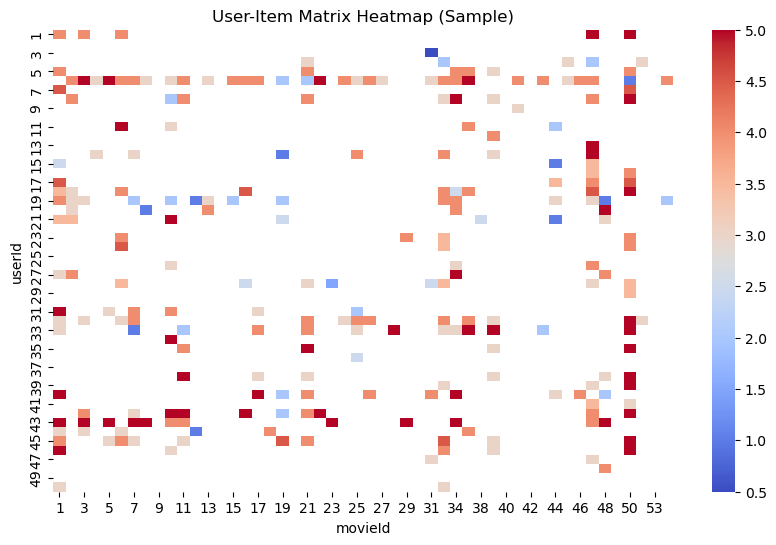

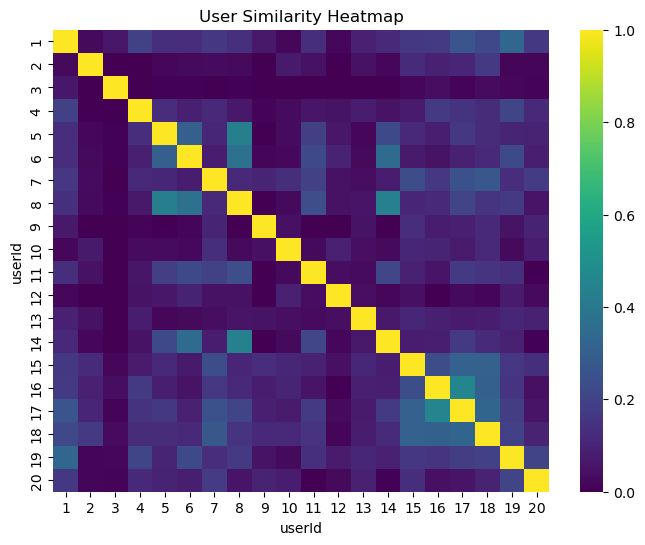

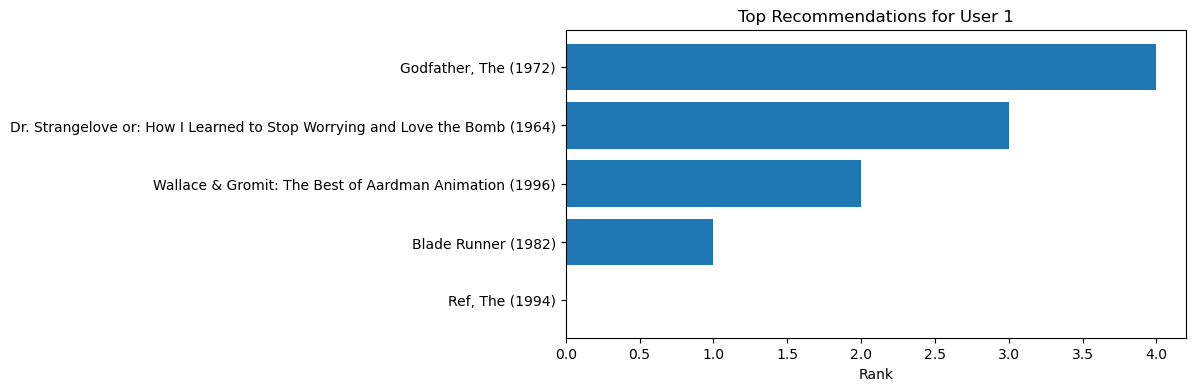

In [9]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
# ============================================
# 2. LOAD DATASET (MovieLens)
# ============================================
ratings = pd.read_csv("C:\\Users\\Rithesh\\Downloads\\archive\\ratings.csv")
movies = pd.read_csv("C:\\Users\\Rithesh\\Downloads\\archive\\movies.csv")

print("Ratings Shape:", ratings.shape)
print("Movies Shape:", movies.shape)
# ============================================
# 3. DATA INSPECTION & PREPROCESSING
# ============================================
print("\n--- Ratings Info ---")
print(ratings.info())

print("\n--- Missing Values ---")
print(ratings.isnull().sum())

print("\n--- Sample Data ---")
print(ratings.head())
# ============================================
# 4. CREATE USER-ITEM MATRIX
# ============================================
user_item_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

print("\nUser-Item Matrix Shape:", user_item_matrix.shape)
# ============================================
# 5. HANDLE MISSING VALUES
# Fill with 0 (common approach)
# ============================================
user_item_filled = user_item_matrix.fillna(0)
# ============================================
# 6. COMPUTE SIMILARITY (COSINE)
# ============================================
user_similarity = cosine_similarity(user_item_filled)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_filled.index,
    columns=user_item_filled.index
)

print("\nUser Similarity Matrix Shape:", user_similarity_df.shape)
# ============================================
# 7. FIND TOP-N SIMILAR USERS
# ============================================
def get_similar_users(user_id, n=5):
    sim_scores = user_similarity_df[user_id].sort_values(ascending=False)
    sim_users = sim_scores.iloc[1:n+1]  # skip itself
    return sim_users

# Example
print("\nTop similar users for User 1:")
print(get_similar_users(1))
# ============================================
# 8. PREDICT RATINGS FOR UNSEEN MOVIES
# ============================================
def predict_ratings(user_id, n_neighbors=5):
    similar_users = get_similar_users(user_id, n_neighbors)

    user_ratings = user_item_filled.loc[user_id]

    predicted_ratings = {}

    for movie in user_item_filled.columns:
        if user_ratings[movie] == 0:  # unseen movie
            weighted_sum = 0
            similarity_sum = 0

            for sim_user, sim_score in similar_users.items():
                rating = user_item_filled.loc[sim_user, movie]
                if rating > 0:
                    weighted_sum += sim_score * rating
                    similarity_sum += sim_score

            if similarity_sum > 0:
                predicted_ratings[movie] = weighted_sum / similarity_sum

    return predicted_ratings
    # ============================================
# 9. TOP-N RECOMMENDATIONS
# ============================================
def recommend_movies(user_id, n=5):
    preds = predict_ratings(user_id)

    sorted_preds = sorted(preds.items(), key=lambda x: x[1], reverse=True)

    top_movies = sorted_preds[:n]

    movie_ids = [movie[0] for movie in top_movies]

    return movies[movies['movieId'].isin(movie_ids)]

# Example
print("\nRecommended Movies for User 1:")
print(recommend_movies(1, 5))
# ============================================
# FAST EVALUATION (OPTIMIZED)
# ============================================

def fast_evaluate(sample_size=500):
    
    # Take smaller sample
    sample_data = ratings.sample(sample_size, random_state=42)
    
    actual = []
    predicted = []
    
    for _, row in sample_data.iterrows():
        user = row['userId']
        movie = row['movieId']
        true_rating = row['rating']
        
        # Get similar users once
        similar_users = get_similar_users(user, 5)
        
        weighted_sum = 0
        similarity_sum = 0
        
        for sim_user, sim_score in similar_users.items():
            rating = user_item_filled.loc[sim_user, movie]
            
            if rating > 0:
                weighted_sum += sim_score * rating
                similarity_sum += sim_score
        
        if similarity_sum > 0:
            pred = weighted_sum / similarity_sum
            
            actual.append(true_rating)
            predicted.append(pred)
    
    # Compute metrics
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    
    print("\nFast Evaluation Results:")
    print("RMSE:", rmse)
    print("MAE:", mae)

# Run
fast_evaluate()
# ============================================
# ANALYSIS TASKS
# ============================================

# Sparsity of matrix
total_elements = user_item_matrix.size
non_zero = np.count_nonzero(user_item_matrix)

sparsity = 1 - (non_zero / total_elements)

print("\nSparsity of User-Item Matrix:", sparsity)
# ============================================
# VISUALIZATION
# ============================================

# 1. HEATMAP (User-Item Matrix - small sample)
plt.figure(figsize=(10,6))
sns.heatmap(user_item_matrix.iloc[:50, :50], cmap='coolwarm')
plt.title("User-Item Matrix Heatmap (Sample)")
plt.show()

# 2. USER SIMILARITY HEATMAP
plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20], cmap='viridis')
plt.title("User Similarity Heatmap")
plt.show()

# 3. TOP RECOMMENDATIONS VISUALIZATION
def plot_recommendations(user_id):
    recs = recommend_movies(user_id, 5)
    
    plt.figure(figsize=(8,4))
    plt.barh(recs['title'], range(len(recs)))
    plt.title(f"Top Recommendations for User {user_id}")
    plt.xlabel("Rank")
    plt.show()

plot_recommendations(1)



scenario 2

Item-User Matrix Shape: (9724, 610)

Similar movies to movieId=1:
movieId
3114    0.572601
480     0.565637
780     0.564262
260     0.557388
356     0.547096
Name: 1, dtype: float64

Recommendations for User 1:
      movieId                              title  \
337       380                   True Lies (1994)   
507       589  Terminator 2: Judgment Day (1991)   
902      1200                      Aliens (1986)   
1550     2087                   Peter Pan (1953)   
2195     2918    Ferris Bueller's Day Off (1986)   

                                        genres  
337   Action|Adventure|Comedy|Romance|Thriller  
507                              Action|Sci-Fi  
902             Action|Adventure|Horror|Sci-Fi  
1550        Animation|Children|Fantasy|Musical  
2195                                    Comedy  

RMSE: 0.9250189172879644

Precision@5: 0.0

Most Popular Movies:
movieId
356     329
318     317
296     307
593     279
2571    278
Name: count, dtype: int64

Least Popular Movies

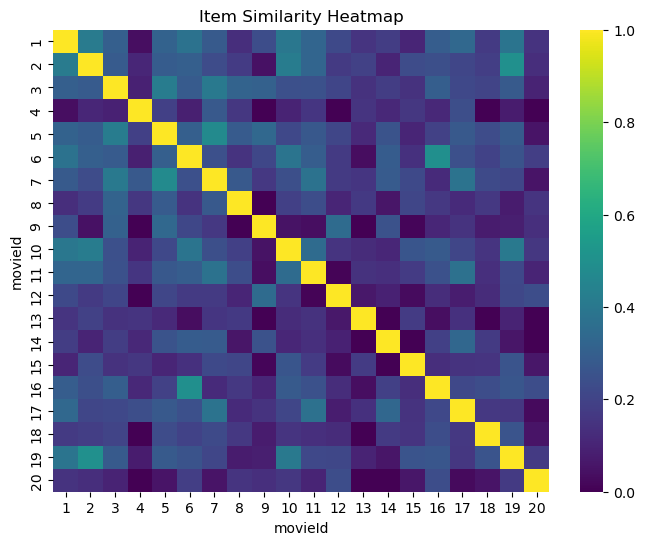

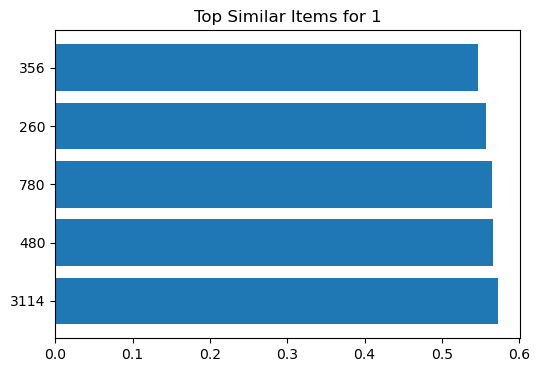


Item-Based Recommendations:
                                  title
337                    True Lies (1994)
507   Terminator 2: Judgment Day (1991)
902                       Aliens (1986)
1550                   Peter Pan (1953)
2195    Ferris Bueller's Day Off (1986)


In [11]:
# 1. IMPORT LIBRARIES
#Refer to cell number 1

# ============================================
# 2. LOAD DATASET
# ============================================
ratings = pd.read_csv("C:\\Users\\Rithesh\\Downloads\\archive\\ratings.csv")
movies = pd.read_csv("C:\\Users\\Rithesh\\Downloads\\archive\\movies.csv")
# ============================================
# 3. CREATE ITEM-USER MATRIX
# ============================================
item_user_matrix = ratings.pivot_table(
    index='movieId',
    columns='userId',
    values='rating'
)

item_user_filled = item_user_matrix.fillna(0)

print("Item-User Matrix Shape:", item_user_filled.shape)
# ============================================
# 4. ITEM SIMILARITY (COSINE)
# ============================================
item_similarity = cosine_similarity(item_user_filled)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_filled.index,
    columns=item_user_filled.index
)
# ============================================
# 5. TOP SIMILAR ITEMS
# ============================================
def get_similar_items(movie_id, n=5):
    sim_scores = item_similarity_df[movie_id].sort_values(ascending=False)
    return sim_scores.iloc[1:n+1]

# Example
print("\nSimilar movies to movieId=1:")
print(get_similar_items(1))
# ============================================
# 6. RECOMMEND ITEMS BASED ON USER HISTORY
# ============================================
def recommend_items(user_id, n=5):
    
    user_ratings = ratings[ratings['userId'] == user_id]
    
    scores = {}
    
    for _, row in user_ratings.iterrows():
        movie = row['movieId']
        rating = row['rating']
        
        similar_items = get_similar_items(movie, 10)
        
        for sim_movie, sim_score in similar_items.items():
            if sim_movie not in user_ratings['movieId'].values:
                scores[sim_movie] = scores.get(sim_movie, 0) + sim_score * rating
    
    # Sort
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    
    top_items = [movie_id for movie_id, _ in sorted_scores[:n]]
    
    return movies[movies['movieId'].isin(top_items)]

# Example
print("\nRecommendations for User 1:")
print(recommend_items(1, 5))
# ============================================
# 7. RMSE EVALUATION (FAST)
# ============================================
def evaluate_rmse(sample_size=500):
    
    sample = ratings.sample(sample_size, random_state=42)
    
    actual = []
    predicted = []
    
    for _, row in sample.iterrows():
        user = row['userId']
        movie = row['movieId']
        true_rating = row['rating']
        
        user_data = ratings[ratings['userId'] == user]
        
        weighted_sum = 0
        similarity_sum = 0
        
        for _, r in user_data.iterrows():
            sim = item_similarity_df.loc[movie, r['movieId']]
            if sim > 0:
                weighted_sum += sim * r['rating']
                similarity_sum += sim
        
        if similarity_sum > 0:
            pred = weighted_sum / similarity_sum
            
            actual.append(true_rating)
            predicted.append(pred)
    
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print("\nRMSE:", rmse)

evaluate_rmse()
# ============================================
# 8. PRECISION@K
# ============================================
def precision_at_k(user_id, k=5, threshold=4.0):
    
    recs = recommend_items(user_id, k)
    rec_movie_ids = recs['movieId'].values
    
    user_data = ratings[ratings['userId'] == user_id]
    
    relevant = user_data[user_data['rating'] >= threshold]['movieId'].values
    
    hit = sum([1 for movie in rec_movie_ids if movie in relevant])
    
    precision = hit / k
    
    print(f"\nPrecision@{k}:", precision)

precision_at_k(1)
# ============================================
# ANALYSIS
# ============================================

# Popular vs niche
movie_counts = ratings['movieId'].value_counts()

print("\nMost Popular Movies:")
print(movie_counts.head())

print("\nLeast Popular Movies:")
print(movie_counts.tail())
# ============================================
# VISUALIZATION
# ============================================

# 1. ITEM SIMILARITY HEATMAP
plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:20, :20], cmap='viridis')
plt.title("Item Similarity Heatmap")
plt.show()

# 2. TOP SIMILAR ITEMS GRAPH
def plot_similar_items(movie_id):
    sims = get_similar_items(movie_id, 5)
    
    plt.figure(figsize=(6,4))
    plt.barh(sims.index.astype(str), sims.values)
    plt.title(f"Top Similar Items for {movie_id}")
    plt.show()

plot_similar_items(1)
# 3. RECOMMENDATION COMPARISON (USER vs ITEM)
def compare_user_item(user_id):
    item_recs = recommend_items(user_id, 5)
    
    print("\nItem-Based Recommendations:")
    print(item_recs[['title']])

compare_user_item(1)


